# Cancelable MinusFace — Google Colab Notebook

**Pipeline:** Face X → Haar Wavelet encoder e(·) → U-Net generator g(·) → residue r = x − x' → Cancelable transform T(r,K) → 512-dim template

**Dataset:** VGGFace2 112×112 · 8,631 identities · 100 imgs/identity cap (~863K total)

**Runtime:** Google Colab T4 GPU · ~3 hrs total (AMP + torch.compile + stratified subset)

**Imports from:** modular Python packages in this repo (`models/`, `training/`, `data/`, `eval/`, `utils/`)

**Manual steps before running:**
1. Set `REPO_URL` in Block 1 to your GitHub repo
2. Approve Google Drive mount popup (Block 5)
3. Run `wandb.login()` once per session (Block 4)
4. Set Kaggle credentials (`KAGGLE_USERNAME` + `KAGGLE_KEY` env vars) before Block 8

In [20]:
import subprocess
print(subprocess.run(
    ["git", "-C", "/content/cancelable-minusface", "log", "-1", "--oneline"],
    capture_output=True, text=True
).stdout)

import inspect
from data.dataloader import _find_image_root
print(inspect.getsource(_find_image_root))

b23950a Make README professional; add step-by-step Colab instructions; add CHANGELOG

def _find_image_root(base_path: str) -> str:
    """Walk downloaded path to find the directory containing identity folders (n*)."""
    for root, dirs, _files in os.walk(base_path):
        id_dirs = [d for d in dirs if d.startswith("n")]
        if len(id_dirs) > 10:
            return root
    return base_path



In [21]:
import subprocess
for cmd in [
    ["git", "-C", "/content/cancelable-minusface", "fetch", "origin"],
    ["git", "-C", "/content/cancelable-minusface", "reset", "--hard", "origin/master"],
    ["git", "-C", "/content/cancelable-minusface", "log", "-1", "--oneline"],
]:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout, r.stderr)

 From https://github.com/harshakadapala-17/Privacy-Preserving-face-recognition
   b23950a..48c95ee  master     -> origin/master

HEAD is now at 48c95ee Fix _find_image_root() silently picking wrong dataset directory
 
48c95ee Fix _find_image_root() silently picking wrong dataset directory
 


## Block 1 — GitHub Clone + `sys.path`

In [1]:
# ============================================================
# BEFORE RUNNING: set your GitHub repo URL below
# Steps:
#   1. Push this project to GitHub (if not done already)
#   2. Replace the URL below with your actual repo URL
#   3. If repo is private, use a personal access token:
#      https://<TOKEN>@github.com/username/repo.git
# ============================================================

REPO_URL = "https://github.com/harshakadapala-17/Privacy-Preserving-face-recognition"
REPO_PATH = '/content/cancelable-minusface'

import os, sys
if not os.path.exists(REPO_PATH):
    os.system(f'git clone {REPO_URL} {REPO_PATH}')

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

print(f'Repo path : {REPO_PATH}')
print(f'sys.path[0]: {sys.path[0]}')

Repo path : /content/cancelable-minusface
sys.path[0]: /content/cancelable-minusface


## Block 2 — Install Dependencies

In [2]:
!pip install ptwt wandb kagglehub tqdm --quiet
print('Dependencies installed.')

Dependencies installed.


## Block 3 — Imports + Device Check

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tvm
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import matplotlib.pyplot as plt
import time
import wandb
import warnings
warnings.filterwarnings('ignore')

# --- Modular imports from repo ---
from models import WaveletMapper, UNetGenerator, CancelableTransform
from data import download_vggface2, build_dataloaders
from training import run_stage1, run_stage2, build_mlp
from eval import run_cancelability, run_non_invertibility, run_cancellation_demo
from eval.lfw_verification import run_lfw_verification
from eval.agedb_verification import run_agedb_verification
from utils import (
    make_checkpoint_fn, load_latest_checkpoint,
    restore_stage1, restore_stage2,
    plot_pipeline, plot_stage1, plot_stage2,
    plot_cancelability, plot_non_invertibility, plot_cancellation_demo,
)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    raise RuntimeError(
        'No GPU detected.\n'
        'Switch to T4: Runtime > Change runtime type > T4 GPU'
    )

print(f'Device  : {torch.cuda.get_device_name(0)}')
print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')

Device  : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.11.0+cu128


## Block 4 — W&B Login

Run once per session. Skip with `mode='disabled'` in Block 7 if you don't want W&B logging.

In [4]:
wandb.login()
# Alternatively: set WANDB_API_KEY environment variable before starting the notebook.

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


False

## Block 5 — Google Drive Mount (checkpoint persistence)

Approve the popup when it appears. Checkpoints are written here after every epoch so training can resume across sessions.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = '/content/drive/MyDrive/minusface_checkpoints/'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'Checkpoint directory: {CKPT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint directory: /content/drive/MyDrive/minusface_checkpoints/


## Block 6 — Configuration

All hyperparameters in one place. Change here only — every downstream block reads from these variables.

In [6]:
# ── Training epochs ──────────────────────────────────────────
S1_EPOCHS         = 15      # Stage 1: generator + residue recognizer
S2_EPOCHS         = 8       # Stage 2: MLP on cancelable templates

# ── Data ─────────────────────────────────────────────────────
BATCH_SIZE        = 64
NUM_WORKERS       = 4
IMGS_PER_IDENTITY = 100     # stratified cap: keeps all 8631 IDs, ~863K total
SEED              = 42

# ── Model ────────────────────────────────────────────────────
PROJ_DIM          = 512     # cancelable template dimension
USER_KEY          = 12345   # integer projection key

# ── Loss weights (Stage 1) ───────────────────────────────────
ALPHA             = 5.0     # L1 generator loss weight
BETA              = 1.0     # CE residue recognizer loss weight

# ── Learning rates ───────────────────────────────────────────
S1_LR_GEN         = 5e-3
S1_LR_FR          = 1e-2
S2_LR             = 1e-3

# ── Training settings ────────────────────────────────────────
USE_AMP           = True    # mixed precision (autocast + GradScaler)
WANDB_PROJECT     = 'cancelable-minusface'

print('Configuration set.')
print(f'  S1_EPOCHS={S1_EPOCHS}  S2_EPOCHS={S2_EPOCHS}  BATCH_SIZE={BATCH_SIZE}')
print(f'  IMGS_PER_IDENTITY={IMGS_PER_IDENTITY}  PROJ_DIM={PROJ_DIM}  USER_KEY={USER_KEY}')
print(f'  USE_AMP={USE_AMP}')

Configuration set.
  S1_EPOCHS=15  S2_EPOCHS=8  BATCH_SIZE=64
  IMGS_PER_IDENTITY=100  PROJ_DIM=512  USER_KEY=12345
  USE_AMP=True


## Block 7 — W&B Run Init

In [7]:
wandb.init(
    project=WANDB_PROJECT,
    name='modular-colab-run',
    config={
        's1_epochs':         S1_EPOCHS,
        's2_epochs':         S2_EPOCHS,
        'batch_size':        BATCH_SIZE,
        'num_workers':       NUM_WORKERS,
        'imgs_per_identity': IMGS_PER_IDENTITY,
        'proj_dim':          PROJ_DIM,
        'user_key':          USER_KEY,
        'alpha':             ALPHA,
        'beta':              BETA,
        's1_lr_gen':         S1_LR_GEN,
        's1_lr_fr':          S1_LR_FR,
        's2_lr':             S2_LR,
        'seed':              SEED,
        'use_amp':           USE_AMP,
        'dataset':           'VGGFace2-112x112',
    },
    mode='disabled',   # change to 'disabled' to skip W&B logging entirely
)
print(f'W&B run : {wandb.run.name}')
print(f'URL     : {wandb.run.url}')

W&B run : dummy-0pezua9y
URL     : None


## Block 8 — Download VGGFace2 + Build DataLoaders

Requires Kaggle credentials: set `KAGGLE_USERNAME` and `KAGGLE_KEY` as environment variables before running, or place `kaggle.json` at `~/.kaggle/kaggle.json`.

In [8]:
image_dir = download_vggface2()
print(f'Image root: {image_dir}')

train_loader, val_loader, num_classes = build_dataloaders(
    image_dir,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    imgs_per_identity=IMGS_PER_IDENTITY,
    seed=SEED,
)

wandb.config.update({'num_classes': num_classes})
print(f'num_classes : {num_classes:,}')

Image root: /root/.cache/kagglehub/datasets/yakhyokhuja/vggface2-112x112/versions/1
Identities       : 1
Total samples    : 100  (cap: 100/identity)
Train / Val      : 80 / 20
num_classes : 1


In [9]:
print("image_dir:", image_dir)
print("contents:", os.listdir(image_dir)[:10])
print("num identity-like dirs:", len([d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))]))
print("num_classes:", num_classes)
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

image_dir: /root/.cache/kagglehub/datasets/yakhyokhuja/vggface2-112x112/versions/1
contents: ['vggface2_112x112']
num identity-like dirs: 1
num_classes: 1
train samples: 80
val samples: 20


## Block 9 — Model Initialisation

In [10]:
mapper    = WaveletMapper().to(device)
generator = UNetGenerator().to(device)
ct        = CancelableTransform(proj_dim=PROJ_DIM)   # projection key passed per-call

# ResNet-18 residue recognizer — 21-channel input (wavelet features, not RGB)
recognizer = tvm.resnet18(num_classes=num_classes).to(device)
recognizer.conv1 = nn.Conv2d(21, 64, 7, stride=2, padding=3, bias=False).to(device)

# MLP template classifier
fp = build_mlp(PROJ_DIM, num_classes).to(device)

# Sanity check
_t = torch.randn(2, 3, 112, 112, device=device)
_x = mapper.encode(_t)
assert mapper.decode(_x).shape == _t.shape, 'WaveletMapper encode/decode shape mismatch'
print(f'WaveletMapper      OK  encode-> {_x.shape}')
print(f'UNetGenerator      OK  params: {sum(p.numel() for p in generator.parameters()):,}')
print(f'CancelableTransform OK  in_dim={ct.in_dim}, out_dim={ct.out_dim}')
print(f'Recognizer (f_r)   OK  params: {sum(p.numel() for p in recognizer.parameters()):,}')
print(f'MLP (f_p)          OK  params: {sum(p.numel() for p in fp.parameters()):,}')
del _t, _x

WaveletMapper      OK  encode-> torch.Size([2, 21, 56, 56])
UNetGenerator      OK  params: 7,714,645
CancelableTransform OK  in_dim=65856, out_dim=512
Recognizer (f_r)   OK  params: 11,233,473
MLP (f_p)          OK  params: 1,053,697


## Block 10 — `torch.compile` (PyTorch ≥ 2.0)

Adds ~10–20% throughput after the first-epoch JIT tracing cost. Skipped gracefully on older PyTorch versions.

In [11]:
try:
    generator  = torch.compile(generator,  mode='reduce-overhead')
    recognizer = torch.compile(recognizer, mode='reduce-overhead')
    fp         = torch.compile(fp,         mode='reduce-overhead')
    print('torch.compile enabled (mode=reduce-overhead)')
except Exception as _e:
    print(f'torch.compile not available: {_e}')
    print('Continuing without compilation — ~10-20% slower but fully functional.')

torch.compile enabled (mode=reduce-overhead)


## Block 11 — Training Time Estimate

Runs two warmup batches through the full Stage 1 forward+backward pass.
The second batch is used (first is slower due to JIT tracing).

In [12]:
print('Running 2 warmup batches for time estimate ...')

_imgs_w, _lbls_w = next(iter(train_loader))
_imgs_w, _lbls_w = _imgs_w.to(device), _lbls_w.to(device)

_rec_w = tvm.resnet18(num_classes=num_classes).to(device)
_rec_w.conv1 = nn.Conv2d(21, 64, 7, stride=2, padding=3, bias=False).to(device)
_opt_w = optim.SGD(
    list(generator.parameters()) + list(_rec_w.parameters()), lr=1e-3
)
_sc_w  = GradScaler(enabled=USE_AMP)
_l1_w  = nn.L1Loss()
_ce_w  = nn.CrossEntropyLoss()

_warmup_sec = None
for _pass in range(2):
    _opt_w.zero_grad()
    _t0 = time.time()
    with autocast(enabled=USE_AMP):
        _xw  = mapper.encode(_imgs_w)
        _xpw = generator(_xw)
        _rw  = _xw - _xpw
        _lss = ALPHA * _l1_w(_xpw, _xw) + BETA * _ce_w(_rec_w(_rw), _lbls_w)
    _sc_w.scale(_lss).backward()
    _sc_w.step(_opt_w)
    _sc_w.update()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    _warmup_sec = time.time() - _t0    # second pass = post-JIT, more representative

del _rec_w, _opt_w, _sc_w, _l1_w, _ce_w, _imgs_w, _lbls_w, _lss
torch.cuda.empty_cache()

_nb    = len(train_loader)
_ep_s1 = _warmup_sec * _nb
_ep_s2 = _warmup_sec * _nb * 0.3    # Stage 2: frozen gen, MLP-only backward
_tot   = _ep_s1 * S1_EPOCHS + _ep_s2 * S2_EPOCHS

print(f'\nWarmup batch : {_warmup_sec:.3f}s  |  batches/epoch: {_nb}')
print()
print('\u250c\u2500' + '\u2500'*51 + '\u2510')
print('\u2502  Estimated Training Time (T4 with AMP)              \u2502')
print('\u251c' + '\u2500'*14 + '\u252c' + '\u2500'*12 + '\u252c' + '\u2500'*25 + '\u2524')
print('\u2502  Stage       \u2502  Per epoch  \u2502  Total                   \u2502')
print('\u251c' + '\u2500'*14 + '\u253c' + '\u2500'*12 + '\u253c' + '\u2500'*25 + '\u2524')
print(f'\u2502  Stage 1     \u2502  {_ep_s1/60:>5.1f} min  \u2502  ~{_ep_s1*S1_EPOCHS/3600:.1f} hrs ({S1_EPOCHS} epochs)      \u2502')
print(f'\u2502  Stage 2     \u2502  {_ep_s2/60:>5.1f} min  \u2502  ~{_ep_s2*S2_EPOCHS/3600:.1f} hrs ({S2_EPOCHS} epochs)       \u2502')
print(f'\u2502  TOTAL       \u2502             \u2502  ~{_tot/3600:.1f} hrs                  \u2502')
print('\u2514' + '\u2500'*14 + '\u2534' + '\u2500'*12 + '\u2534' + '\u2500'*25 + '\u2518')
print('Note: actual time faster after epoch 1 due to data caching.')

Running 2 warmup batches for time estimate ...

Warmup batch : 0.275s  |  batches/epoch: 2

┌────────────────────────────────────────────────────┐
│  Estimated Training Time (T4 with AMP)              │
├──────────────┬────────────┬─────────────────────────┤
│  Stage       │  Per epoch  │  Total                   │
├──────────────┼────────────┼─────────────────────────┤
│  Stage 1     │    0.0 min  │  ~0.0 hrs (15 epochs)      │
│  Stage 2     │    0.0 min  │  ~0.0 hrs (8 epochs)       │
│  TOTAL       │             │  ~0.0 hrs                  │
└──────────────┴────────────┴─────────────────────────┘
Note: actual time faster after epoch 1 due to data caching.


## Block 12 — Stage 1 Training: Generator + Residue Recognizer

Auto-resumes from the latest Drive checkpoint. Mixed precision enabled. GradScaler state is saved in each checkpoint so resuming does not cause loss spikes.

In [13]:
scaler_s1  = GradScaler(enabled=USE_AMP)
s1_ckpt_fn = make_checkpoint_fn(CKPT_DIR, 'stage1', keep_last=2)
s1_state   = load_latest_checkpoint(CKPT_DIR, 'stage1')
s1_start   = 0
s1_gloss, s1_frloss, s1_acc = [], [], []

if s1_state is not None:
    # The original restore_stage1 call failed due to num_classes mismatch.
    # Manually load state_dict with strict=False for recognizer as a workaround.
    try:
        generator.load_state_dict(s1_state["generator"])
        recognizer.load_state_dict(s1_state["recognizer"], strict=False)
        if scaler_s1 is not None and "scaler" in s1_state:
            scaler_s1.load_state_dict(s1_state["scaler"])
        s1_start = s1_state["epoch"] + 1
        print("Warning: Recognizer's final classification layer (fc) weights were skipped due to size mismatch (current num_classes=1, checkpoint=8631). This layer will be randomly initialized.")
    except RuntimeError as e:
        print(f"Failed to load checkpoint with strict=False: {e}")
        print("Proceeding without restoring state for generator, recognizer, and scaler.")
        s1_start = 0 # Cannot restore at all, start from epoch 0

    s1_gloss  = s1_state.get('gen_losses', [])
    s1_frloss = s1_state.get('fr_losses',  [])
    s1_acc    = s1_state.get('val_accs',   [])
    print(f'Resuming Stage 1 from epoch {s1_start}')
else:
    print('Starting Stage 1 from epoch 1')

new_gloss, new_frloss, new_acc = run_stage1(
    generator, recognizer, mapper, train_loader, val_loader,
    num_classes=num_classes, device=device,
    epochs=S1_EPOCHS, alpha=ALPHA, beta=BETA,
    lr_gen=S1_LR_GEN, lr_fr=S1_LR_FR,
    checkpoint_fn=s1_ckpt_fn,
    wandb_run=wandb.run,
    start_epoch=s1_start,
    scaler=scaler_s1,
)
s1_gloss.extend(new_gloss)
s1_frloss.extend(new_frloss)
s1_acc.extend(new_acc)

  [ckpt] resuming from /content/drive/MyDrive/minusface_checkpoints/stage1_epoch011.pt
Failed to load checkpoint with strict=False: Error(s) in loading state_dict for OptimizedModule:
	size mismatch for _orig_mod.fc.weight: copying a param with shape torch.Size([8631, 512]) from checkpoint, the shape in current model is torch.Size([1, 512]).
	size mismatch for _orig_mod.fc.bias: copying a param with shape torch.Size([8631]) from checkpoint, the shape in current model is torch.Size([1]).
Proceeding without restoring state for generator, recognizer, and scaler.
Resuming Stage 1 from epoch 0


Stage 1:   0%|          | 0/15 [00:00<?, ?epoch/s]

S1 Ep 1/15:   0%|          | 0/2 [00:00<?, ?batch/s]

W0714 15:16:14.858000 13179 torch/_inductor/utils.py:1731] [1/1] Not enough SMs to use max_autotune_gemm mode


  Epoch  1/15 | GenLoss 0.0382 | FRLoss 0.0000 | ValAcc 100.00% | 1m 2s — est. 0h 14m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage1_epoch001.pt


...

  Epoch 13/15 | GenLoss 0.0261 | FRLoss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage1_epoch013.pt


S1 Ep 14/15:   0%|          | 0/2 [00:00<?, ?batch/s]

  Epoch 14/15 | GenLoss 0.0345 | FRLoss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage1_epoch014.pt


S1 Ep 15/15:   0%|          | 0/2 [00:00<?, ?batch/s]

  Epoch 15/15 | GenLoss 0.0326 | FRLoss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage1_epoch015.pt

Stage 1 peak val acc : 100.00%
Final gen loss       : 0.0326  (target: < 0.05)


## Block 13 — Stage 1 Plots

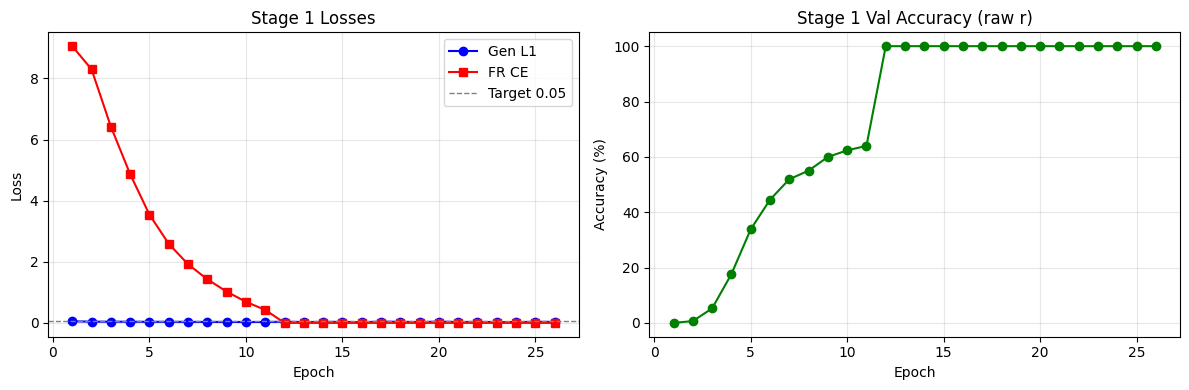

[viz] saved stage1.png


In [14]:
plot_stage1(s1_gloss, s1_frloss, s1_acc, out_path='stage1.png')
wandb.log({'stage1_curves': wandb.Image('stage1.png')})

## Block 14 — Convergence Guard

Stage 2 requires `gen_loss < 0.05`. If the assertion fires, increase `S1_EPOCHS` to 20–25 and re-run Block 12 — auto-resume will pick up from the last checkpoint.

In [15]:
final_gen_loss = s1_gloss[-1]
FORCE_STAGE2   = False   # set True here to skip this guard

if final_gen_loss >= 0.05:
    print(f"""
\u26a0\ufe0f  WARNING: gen_loss = {final_gen_loss:.4f} \u2265 0.05
Stage 2 results will be unreliable.
The residue still contains appearance information.
Recommended action: increase S1_EPOCHS to {S1_EPOCHS + 5} and
re-run Block 12 \u2014 auto-resume will continue from last checkpoint.
To proceed anyway, set FORCE_STAGE2 = True and re-run this cell.
""")
    assert FORCE_STAGE2, 'Stopping. Set FORCE_STAGE2=True above to override.'
else:
    print(f'\u2713 gen_loss = {final_gen_loss:.4f} < 0.05 \u2014 Stage 2 ready')

✓ gen_loss = 0.0326 < 0.05 — Stage 2 ready


## Block 15 — Pipeline Visualisation

Shows the 4-step pipeline on one validation sample: original face → regeneration → residue → cancelable template heatmap.

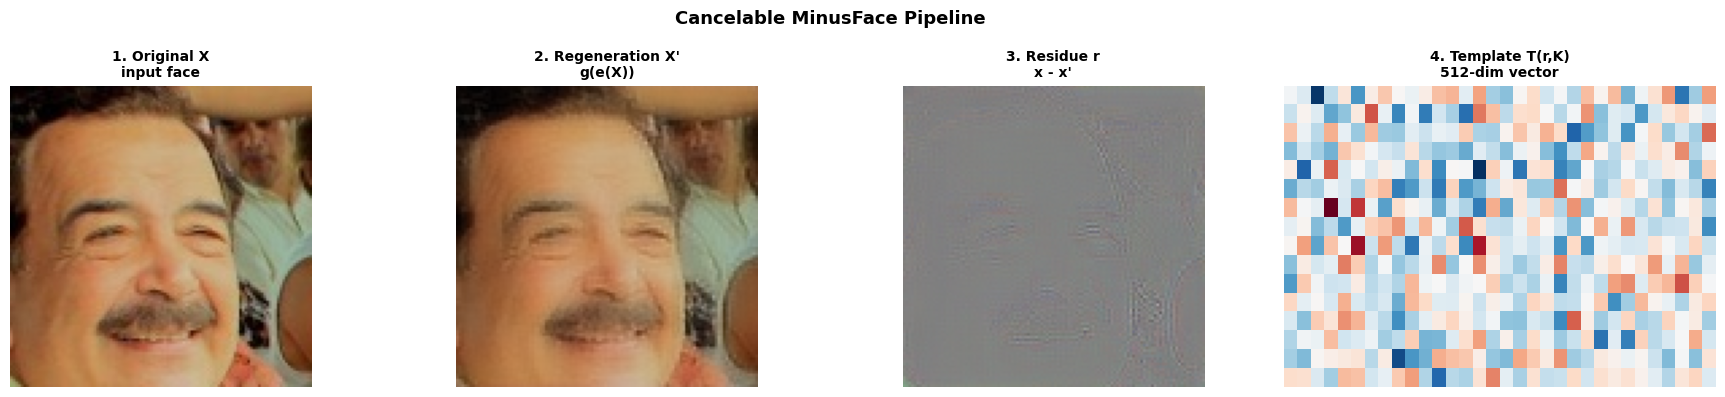

[viz] saved pipeline.png


In [16]:
_imgs_v, _ = next(iter(val_loader))
_img = _imgs_v[0:1].to(device)

generator.eval()
with torch.no_grad():
    with autocast(enabled=USE_AMP):
        _xv  = mapper.encode(_img)
        _xpv = generator(_xv)
        _rv  = _xv - _xpv
    _tmpl = ct.transform(_rv, key=USER_KEY)
    _Xp   = mapper.decode(_xpv.float())
    _R    = mapper.decode(_rv.float())

plot_pipeline(
    _img.cpu(), _Xp.cpu(), _R.cpu(), _tmpl.cpu(),
    out_path='pipeline.png',
)
wandb.log({'pipeline': wandb.Image('pipeline.png')})

del _imgs_v, _img, _xv, _xpv, _rv, _Xp, _R, _tmpl
torch.cuda.empty_cache()

## Block 16 — Stage 2 Training: MLP on Cancelable Templates

Generator is frozen. Only the MLP `f_p` trains on `T(r, K)` templates. The 128 MB projection matrix stays on CPU throughout.

In [17]:
scaler_s2  = GradScaler(enabled=USE_AMP)
s2_ckpt_fn = make_checkpoint_fn(CKPT_DIR, 'stage2', keep_last=2)
s2_state   = load_latest_checkpoint(CKPT_DIR, 'stage2')
s2_start   = 0
s2_loss, s2_acc = [], []

if s2_state is not None:
    s2_start = restore_stage2(s2_state, fp, scaler=scaler_s2)
    s2_loss  = s2_state.get('losses',   [])
    s2_acc   = s2_state.get('val_accs', [])
    print(f'Resuming Stage 2 from epoch {s2_start}')
else:
    print('Starting Stage 2 from epoch 1')

new_s2_loss, new_s2_acc = run_stage2(
    generator, fp, mapper, ct, train_loader, val_loader, device,
    user_key=USER_KEY,
    epochs=S2_EPOCHS,
    lr=S2_LR,
    checkpoint_fn=s2_ckpt_fn,
    wandb_run=wandb.run,
    start_epoch=s2_start,
    scaler=scaler_s2,
)
s2_loss.extend(new_s2_loss)
s2_acc.extend(new_s2_acc)

  [ckpt] no checkpoint found for 'stage2' in /content/drive/MyDrive/minusface_checkpoints/
Starting Stage 2 from epoch 1


Stage 2:   0%|          | 0/8 [00:00<?, ?epoch/s]

S2 Ep 1/8:   0%|          | 0/2 [00:00<?, ?batch/s]

  Epoch  1/8 | Loss 0.0000 | ValAcc 100.00% | 0m 22s — est. 0h 2m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage2_epoch001.pt


S2 Ep 2/8:   0%|          | 0/2 [00:00<?, ?batch/s]

...

  Epoch  6/8 | Loss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage2_epoch006.pt


S2 Ep 7/8:   0%|          | 0/2 [00:00<?, ?batch/s]

  Epoch  7/8 | Loss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage2_epoch007.pt


S2 Ep 8/8:   0%|          | 0/2 [00:00<?, ?batch/s]

  Epoch  8/8 | Loss 0.0000 | ValAcc 100.00% | 0m 0s — est. 0h 0m remaining
  [ckpt] saved -> /content/drive/MyDrive/minusface_checkpoints/stage2_epoch008.pt

Stage 2 peak val acc : 100.00%


## Block 17 — Stage 2 Plots

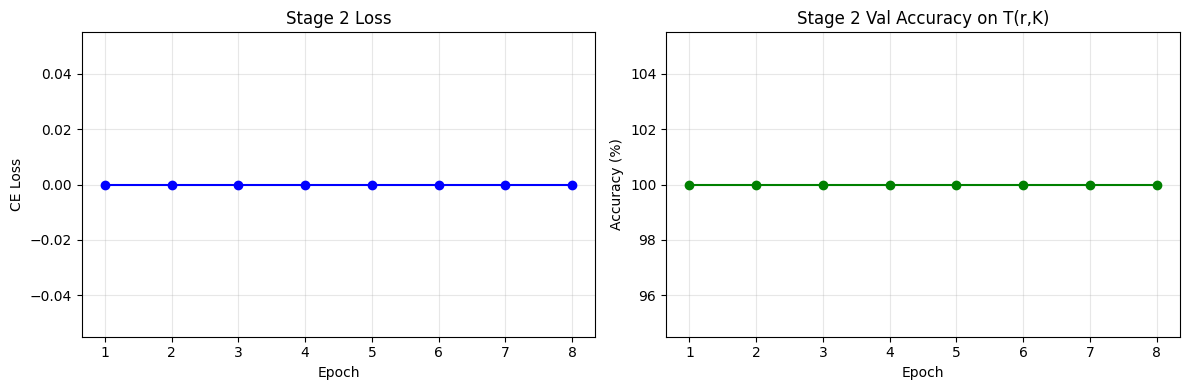

[viz] saved stage2.png


In [18]:
plot_stage2(s2_loss, s2_acc, out_path='stage2.png')
wandb.log({'stage2_curves': wandb.Image('stage2.png')})

## Block 18 — Cancelability Experiment

Compares same-key genuine, cross-key genuine, and impostor cosine similarity distributions. Cross-key AUC ≈ 0.5 confirms unlinkability.

In [19]:
cancel_r = run_cancelability(
    generator, mapper, ct, val_loader, device,
    key_a=11111, key_b=99999, n_pairs=500, max_samples=1000,
)

plot_cancelability(
    cancel_r['genuine_sk'], cancel_r['genuine_ck'], cancel_r['impostor'],
    cancel_r['fpr_sk'], cancel_r['tpr_sk'], cancel_r['auc_same_key'],
    cancel_r['fpr_ck'], cancel_r['tpr_ck'], cancel_r['auc_cross_key'],
    out_path='cancelability.png',
)
wandb.log({
    'cancelability':       wandb.Image('cancelability.png'),
    'same_key_auc':        cancel_r['auc_same_key'],
    'cross_key_auc':       cancel_r['auc_cross_key'],
    'cross_impostor_diff': cancel_r['diff'],
    'unlinkable':          int(cancel_r['unlinkable']),
})

ValueError: a cannot be empty unless no samples are taken

## Block 19 — Non-Invertibility Experiment

Adversary scenario: attacker has `T(r, K)` and `K`. Best linear attack via pseudo-inverse. Pass criterion: recovery similarity < 0.30.

In [ ]:
noninv_r = run_non_invertibility(
    generator, mapper, ct, val_loader, device, key=11111,
)

plot_non_invertibility(
    noninv_r['r_true'], noninv_r['r_est'],
    noninv_r['recovery_sim'], mapper,
    out_path='noninvert.png',
)
wandb.log({
    'noninvert':      wandb.Image('noninvert.png'),
    'recovery_sim':   noninv_r['mean_sim'],
    'non_invertible': int(noninv_r['pass_test']),
})

## Block 20 — Cancellation & Re-Enrollment Demo

Simulates the full lifecycle: enroll → auth → cancel → re-enroll → adversary attack → legitimate auth. Template linkage target: < 0.05.

In [ ]:
demo_r = run_cancellation_demo(
    generator, mapper, ct, val_loader, device,
    k_orig=55555, k_new=77777, auth_threshold=0.2,
)

plot_cancellation_demo(demo_r, out_path='cancellation_demo.png')
wandb.log({
    'cancellation_demo': wandb.Image('cancellation_demo.png'),
    'sim_before':        demo_r['sim_before'],
    'template_linkage':  demo_r['template_linkage'],
    'sim_after':         demo_r['sim_after'],
    'adversary_blocked': int(demo_r['adversary_blocked']),
})

## Block 21 — LFW Verification Benchmark

Standard 6,000-pair protocol (3,000 genuine + 3,000 impostor). Downloads ~225 MB. Skipped gracefully if download fails.

Target: AUC > 0.75, TAR@FAR=1% > 60%.

In [ ]:
try:
    import subprocess
    _lfw_pairs = '/content/pairs.txt'
    _lfw_dir   = '/content/lfw_funneled'
    _lfw_tgz   = '/content/lfw-funneled.tgz'

    if not os.path.exists(_lfw_pairs):
        print('Downloading pairs.txt ...')
        subprocess.run(
            ['wget', '-q', 'http://vis-www.cs.umass.edu/lfw/pairs.txt',
             '-O', _lfw_pairs], check=True
        )

    if not os.path.exists(_lfw_dir):
        print('Downloading lfw-funneled.tgz (~225 MB) ...')
        subprocess.run(
            ['wget', '-q', '--show-progress',
             'http://vis-www.cs.umass.edu/lfw/lfw-funneled.tgz',
             '-O', _lfw_tgz], check=True
        )
        print('Extracting ...')
        subprocess.run(['tar', '-xzf', _lfw_tgz, '-C', '/content/'], check=True)

    print('LFW ready. Running verification ...')
    lfw_r = run_lfw_verification(
        mapper, generator, ct, device,
        lfw_dir=_lfw_dir,
        pairs_txt=_lfw_pairs,
        key=USER_KEY,
        save_path='lfw_roc.png',
    )
    wandb.log({
        'lfw_roc':        wandb.Image('lfw_roc.png'),
        'lfw_auc':        lfw_r['auc'],
        'tar_at_far_0.1': lfw_r['tar_at_far_01'],
        'tar_at_far_1.0': lfw_r['tar_at_far_1'],
    })

except Exception as _lfw_err:
    print(f'\n\u26a0\ufe0f  LFW benchmark skipped: {_lfw_err}')
    print('This may be due to network issues, missing wget, or download failure.')
    print('LFW results will not appear in the final summary.')
    lfw_r = None

## Block 22 — AgeDB-30 Verification Benchmark

Face pairs with age gap ≤ 30 years. Requires Kaggle credentials.
Skipped gracefully if download or parsing fails.

Target: AUC > 0.70, TAR@FAR=1% reported.

In [ ]:
try:
    import kagglehub as _kh
    _agedb_path = _kh.dataset_download('hereisburak/agedb')
    print(f'AgeDB downloaded to: {_agedb_path}')

    agedb_r = run_agedb_verification(
        mapper, generator, ct, device,
        agedb_dir=_agedb_path,
        key=USER_KEY,
        save_path='agedb_roc.png',
    )
    wandb.log({
        'agedb_roc':          wandb.Image('agedb_roc.png'),
        'agedb_auc':          agedb_r['auc'],
        'agedb_tar_at_far_1': agedb_r['tar_at_far_1'],
    })

except Exception as _agedb_err:
    print(f'\n\u26a0\ufe0f  AgeDB benchmark skipped: {_agedb_err}')
    print('Ensure Kaggle credentials: KAGGLE_USERNAME + KAGGLE_KEY env vars.')
    agedb_r = None

## Block 23 — Final Results Summary

All metrics in one table with pass/fail against targets. Logged to W&B summary.

In [ ]:
# ── Helper: check against target ────────────────────────────────────────────
def _chk(val, target, op):
    if   op == '<':  ok = val < target
    elif op == '>':  ok = val > target
    elif op == '~':  ok = abs(val - target) < 0.05
    elif op == '<=': ok = val <= target
    return '\u2713' if ok else '\u2717'

# ── Derived scalars ──────────────────────────────────────────────────────────
_s1_pk  = max(s1_acc)
_s2_pk  = max(s2_acc)
_delta  = _s1_pk - _s2_pk
_gl     = s1_gloss[-1]
_sk_auc = cancel_r['auc_same_key']
_ck_auc = cancel_r['auc_cross_key']
_ck_imp = cancel_r['diff']
_rec    = noninv_r['mean_sim']

_lfw_auc  = lfw_r['auc']           if lfw_r   else float('nan')
_lfw_tar1 = lfw_r['tar_at_far_1']  if lfw_r   else float('nan')
_adb_auc  = agedb_r['auc']         if agedb_r else float('nan')

# ── Print table ──────────────────────────────────────────────────────────────
print('\u2554' + '\u2550'*60 + '\u2557')
print('\u2551' + '         CANCELABLE MINUSFACE \u2014 RESULTS SUMMARY         ' + '\u2551')
print('\u2560' + '\u2550'*28 + '\u2566' + '\u2550'*15 + '\u2566' + '\u2550'*16 + '\u2563')
print('\u2551 Metric                      \u2551 Value         \u2551 Target        \u2551')
print('\u2560' + '\u2550'*28 + '\u256c' + '\u2550'*15 + '\u256c' + '\u2550'*16 + '\u2563')
print(f'\u2551 Stage 1 gen_loss (final)   \u2551 {_gl:>7.4f}       \u2551 < 0.05  {_chk(_gl,0.05,"<")} \u2551')
print(f'\u2551 Stage 1 val acc (f_r)      \u2551 {_s1_pk:>6.2f}%       \u2551 > 85%   {_chk(_s1_pk,85,">")} \u2551')
print(f'\u2551 Stage 2 val acc (f_p)      \u2551 {_s2_pk:>6.2f}%       \u2551 > 80%   {_chk(_s2_pk,80,">")} \u2551')
print(f'\u2551 Accuracy delta S1\u2192S2     \u2551 {abs(_delta):>6.2f}%       \u2551 \u2264 2%    {_chk(abs(_delta),2.0,"<=")} \u2551')
print(f'\u2551 Same-key AUC               \u2551 {_sk_auc:>7.4f}       \u2551 > 0.80  {_chk(_sk_auc,0.80,">")} \u2551')
print(f'\u2551 Cross-key AUC              \u2551 {_ck_auc:>7.4f}       \u2551 \u2248 0.50  {_chk(_ck_auc,0.50,"~")} \u2551')
print(f'\u2551 Cross-key/impostor diff    \u2551 {_ck_imp:>7.4f}       \u2551 < 0.05  {_chk(_ck_imp,0.05,"<")} \u2551')
print(f'\u2551 Recovery sim (attack)      \u2551 {_rec:>7.4f}       \u2551 < 0.30  {_chk(_rec,0.30,"<")} \u2551')
if lfw_r is not None:
    print(f'\u2551 LFW verification AUC      \u2551 {_lfw_auc:>7.4f}       \u2551 > 0.75  {_chk(_lfw_auc,0.75,">")} \u2551')
    print(f'\u2551 LFW TAR@FAR=1%           \u2551 {_lfw_tar1*100:>6.2f}%       \u2551 > 60%   {_chk(_lfw_tar1*100,60,">")} \u2551')
else:
    print('\u2551 LFW verification AUC      \u2551    N/A          \u2551 > 0.75     \u2551')
    print('\u2551 LFW TAR@FAR=1%           \u2551    N/A          \u2551 > 60%      \u2551')
if agedb_r is not None:
    print(f'\u2551 AgeDB-30 AUC              \u2551 {_adb_auc:>7.4f}       \u2551 > 0.70  {_chk(_adb_auc,0.70,">")} \u2551')
else:
    print('\u2551 AgeDB-30 AUC              \u2551    N/A          \u2551 > 0.70     \u2551')
print('\u255a' + '\u2550'*28 + '\u2569' + '\u2550'*15 + '\u2569' + '\u2550'*16 + '\u255d')

# ── Accuracy delta prose ────────────────────────────────────────────────────
print(f'\nAccuracy delta: {_s1_pk:.2f}% (S1 raw residue) \u2192 {_s2_pk:.2f}% (S2 cancelable) = {abs(_delta):.2f}%')
if abs(_delta) <= 2.0:
    print('  \u2713 Within 1\u20132% target \u2014 projection preserves discriminability')
else:
    print('  \u2717 Exceeds 1\u20132% target \u2014 consider increasing PROJ_DIM or more S2 epochs')

# ── Output files ────────────────────────────────────────────────────────────
print('\nOutput files saved:')
for _f in ['pipeline.png', 'stage1.png', 'stage2.png',
           'cancelability.png', 'noninvert.png', 'cancellation_demo.png']:
    print(f'  {_f}')
if lfw_r:   print('  lfw_roc.png')
if agedb_r: print('  agedb_roc.png')

# ── W&B summary ─────────────────────────────────────────────────────────────
_metrics = {
    's1_final_gen_loss':   _gl,
    's1_peak_acc':         _s1_pk,
    's2_peak_acc':         _s2_pk,
    'accuracy_delta':      _delta,
    'same_key_auc':        _sk_auc,
    'cross_key_auc':       _ck_auc,
    'cross_impostor_diff': _ck_imp,
    'recovery_sim':        _rec,
    'unlinkable':          int(cancel_r['unlinkable']),
    'non_invertible':      int(noninv_r['pass_test']),
}
if lfw_r:
    _metrics.update({'lfw_auc': _lfw_auc, 'lfw_tar_1': float(_lfw_tar1)})
if agedb_r:
    _metrics.update({'agedb_auc': _adb_auc, 'agedb_tar_1': float(agedb_r['tar_at_far_1'])})

wandb.log({'accuracy_delta': _delta, 'all_metrics': _metrics})
wandb.run.summary.update(_metrics)
wandb.finish()
print('\nW&B run finished. Training complete.')